# 🥈 Arquitetura Medalhão: Camada Silver (Clean & Parsed Data)

**Projeto:** Foodhunter (RAG System para Recomendação de Restaurantes)
**Objetivo desta camada:** A camada Silver é responsável pela higienização, tipagem e enriquecimento estrutural dos dados da camada Bronze. 

**Principais Transformações:**
1. **Filtragem Lógica:** Manter apenas restaurantes abertos.
2. **Parsing de JSON:** Converter a coluna `attributes` (String) para Dicionário Python.
3. **Feature Engineering Básica:** Extrair colunas booleanas e numéricas (`has_delivery`, `price_range`) de dentro do dicionário para facilitar os filtros do RAG.
4. **Casting de Embeddings:** Converter as Strings gigantes da coluna `embedding` de volta para Listas nativas (Arrays).
5. **Evolução de Formato:** Salvar os dados processados em `.parquet` (colunar) para preservar as tipagens complexas.

In [4]:
import pandas as pd
import ast
import os

# Configurações visuais do Pandas
# pd.set_option('display.max_columns', None)

## 1. Ingestão da Camada Bronze
Lendo o arquivo bruto utilizando caminhos relativos dinâmicos (`os.path`) para garantir portabilidade entre diferentes ambientes e execuções no VS Code.

In [7]:
diretorio_atual = os.getcwd()
diretorio_raiz = os.path.dirname(diretorio_atual)
caminho_bronze = os.path.join(diretorio_raiz, '1. bronze', 'restaurants_with_embeddings.csv')

print(f"Lendo dados de: {caminho_bronze}")
df = pd.read_csv(caminho_bronze)

# Filtro 1: Apenas restaurantes em operação
tamanho_original = len(df)
df = df[df['is_open'] == 1].copy()
print(f"Restaurantes filtrados (Abertos): {len(df)} de {tamanho_original}")

display(df.head())

Lendo dados de: c:\Faculdade - IA\Projeto AC2\RAG-Sapato\1. bronze\restaurants_with_embeddings.csv
Restaurantes filtrados (Abertos): 34987 de 34987


,business_id,name,address,city,state,postal_code,latitude,longitude,stars,review_count,is_open,attributes,categories,hours,price,description,embedding
0,MTSW4McQd7CbVtyjqoe9mw,St Honore Pastries,935 Race St,Philadelphia,PA,19107,39.955505,-75.155564,4.0,80,1,"{'RestaurantsDelivery': 'False', 'RestaurantsP...",Restaurants Food Bubble Tea Coffee & Tea B...,"{'Wednesday': '7:0-20:0', 'Thursday': '7:0-20:...",1,Restaurants Food Bubble Tea Coffee & Tea B...,"[0.0035318147856742144, -0.008946051821112633,..."
1,CF33F8-E6oudUQ46HnavjQ,Sonic Drive-In,615 S Main St,Ashland City,TN,37015,36.269593,-87.058943,2.0,6,1,"{'RestaurantsDelivery': 'True', 'RestaurantsPr...",Burgers Fast Food Sandwiches Food Ice Crea...,"{'Wednesday': '6:0-22:0', 'Thursday': '6:0-22:...",1,Burgers Fast Food Sandwiches Food Ice Crea...,"[-0.005798297934234142, 0.013337074778974056, ..."
2,bBDDEgkFA1Otx9Lfe7BZUQ,Sonic Drive-In,2312 Dickerson Pike,Nashville,TN,37207,36.208102,-86.768170,1.5,10,1,"{'RestaurantsDelivery': 'True', 'RestaurantsPr...",Ice Cream & Frozen Yogurt Fast Food Burgers ...,"{'Wednesday': '6:0-21:0', 'Thursday': '6:0-16:...",1,Ice Cream & Frozen Yogurt Fast Food Burgers ...,"[0.01703026331961155, 0.0003804313892032951, 0..."
3,eEOYSgkmpB90uNA7lDOMRA,Vietnamese Food Truck,NaN,Tampa Bay,FL,33602,27.955269,-82.456320,4.0,10,1,"{'RestaurantsDelivery': None, 'RestaurantsPric...",Vietnamese Food Restaurants Food Trucks,"{'Wednesday': '11:0-14:0', 'Thursday': '11:0-1...",unknown,Vietnamese Food Restaurants Food Trucks pri...,"[0.01165863499045372, 0.007707028184086084, -0..."
4,il_Ro8jwPlHresjw9EGmBg,Denny's,8901 US 31 S,Indianapolis,IN,46227,39.637133,-86.127217,2.5,28,1,"{'RestaurantsDelivery': 'True', 'RestaurantsPr...",American (Traditional) Restaurants Diners B...,"{'Wednesday': '6:0-22:0', 'Thursday': '6:0-22:...",1,American (Traditional) Restaurants Diners B...,"[0.03403853625059128, -0.01017673872411251, 0...."


## 2. Parsing da Coluna Attributes
Conforme identificado na camada Bronze, a coluna `attributes` veio como uma string suja. Vamos limpá-la e transformá-la em um dicionário acessível.

In [8]:
def parse_dict_string(x):
    """Converte string de dicionário com falhas de escape em dict do Python"""
    if pd.isna(x): return {}
    try:
        clean_str = str(x).replace('""', '"').replace("u'", "'")
        return ast.literal_eval(clean_str)
    except:
        return {}

df['attributes_dict'] = df['attributes'].apply(parse_dict_string)

# Checagem visual para garantir que virou um dicionário real
print("Tipo da nova coluna:", type(df['attributes_dict'].iloc[0]))
display(df[['name', 'attributes_dict']].head(2))

Tipo da nova coluna: <class 'dict'>


,name,attributes_dict
0,St Honore Pastries,"{'RestaurantsDelivery': 'False', 'RestaurantsP..."
1,Sonic Drive-In,"{'RestaurantsDelivery': 'True', 'RestaurantsPr..."


## 3. Extração de Features (Flattening)
Agora que temos dicionários reais, podemos "achatar" (flatten) as informações cruciais em colunas próprias. Isso é vital para a Camada Gold, pois permitirá que o sistema RAG filtre restaurantes antes de calcular a Similaridade de Cosseno.

In [12]:
# Extração de booleanos
df['has_delivery'] = df['attributes_dict'].apply(lambda x: x.get('RestaurantsDelivery', 'False') == 'True')
df['has_outdoor'] = df['attributes_dict'].apply(lambda x: x.get('OutdoorSeating', 'False') == 'True')

# Extração e normalização de inteiros
def get_price(x):
    val = x.get('RestaurantsPriceRange2', '1')
    return int(val) if val and val.isdigit() else 1
    
df['price_range'] = df['attributes_dict'].apply(get_price)

print("Features extraídas com sucesso!")

display(
    df[
        [
            'name',
            'has_delivery',
            'has_outdoor',
            'price_range',
            'stars'
        ]
    ].head(10)
)


Features extraídas com sucesso!


,name,has_delivery,has_outdoor,price_range,stars
0,St Honore Pastries,False,False,1,4.0
1,Sonic Drive-In,True,True,1,2.0
2,Sonic Drive-In,True,True,1,1.5
3,Vietnamese Food Truck,False,False,1,4.0
4,Denny's,True,False,1,2.5
5,Tuna Bar,True,True,2,4.0
6,BAP,False,False,1,4.5
7,Hibachi Express,True,False,2,4.0
8,Romano's Macaroni Grill,True,True,2,2.5
9,Domino's Pizza,False,False,1,3.5


### 3.1 Visualizando as Features Extraídas
Entender a distribuição dos dados de delivery e preço para validar se a extração ocorreu conforme o esperado.

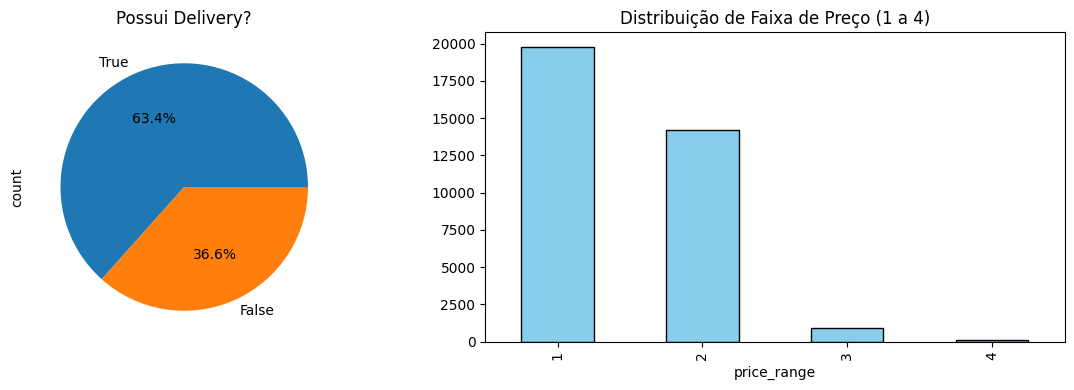

In [5]:
import matplotlib.pyplot as plt

# Usando um plot nativo do pandas para visualizar rapidamente a distribuição
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['has_delivery'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=axes[0], title='Possui Delivery?')
df['price_range'].value_counts().sort_index().plot(kind='bar', color='skyblue', edgecolor='black', ax=axes[1], title='Distribuição de Faixa de Preço (1 a 4)')

plt.tight_layout()
plt.show()

## 4. Correção Estrutural dos Embeddings
Transformando a representação em texto dos vetores para arrays reais de Ponto Flutuante (Float). Sem isso, o banco de dados vetorial rejeitaria os dados.

In [14]:
# Convertendo string para lista
df['embedding_list'] = df['embedding'].apply(lambda x: ast.literal_eval(x) if isinstance(x, str) else x)

# Validação do cast
primeiro_vetor = df['embedding_list'].iloc[0]
print(f"Tipo atual da célula: {type(primeiro_vetor)}")
print(f"Dimensões do embedding (Tamanho do vetor): {len(primeiro_vetor)}")



Tipo atual da célula: <class 'list'>
Dimensões do embedding (Tamanho do vetor): 384


## 5. Seleção Final e Armazenamento (Parquet)
Removendo colunas temporárias e obsoletas. O armazenamento em formato `.parquet` garante que a coluna de listas (`embedding_list`) não volte a ser string (como aconteceria se salvássemos em CSV).

In [7]:
colunas_para_remover = ['attributes', 'attributes_dict', 'hours', 'is_open', 'embedding']
df_silver = df.drop(columns=colunas_para_remover, errors='ignore')

caminho_saida = os.path.join(diretorio_atual, 'silver_data.parquet')
df_silver.to_parquet(caminho_saida, engine='pyarrow', index=False)

print(f"✅ Camada Silver concluída e salva com sucesso em:\n{caminho_saida}")

# Exibe o schema final que será consumido pela camada Gold
df_silver.info()

✅ Camada Silver concluída e salva com sucesso em:
c:\Faculdade - IA\Projeto AC2\RAG-Sapato\2. silver\silver_data.parquet
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34987 entries, 0 to 34986
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   business_id     34987 non-null  object 
 1   name            34987 non-null  object 
 2   address         34662 non-null  object 
 3   city            34987 non-null  object 
 4   state           34987 non-null  object 
 5   postal_code     34983 non-null  object 
 6   latitude        34987 non-null  float64
 7   longitude       34987 non-null  float64
 8   stars           34987 non-null  float64
 9   review_count    34987 non-null  int64  
 10  categories      34987 non-null  object 
 11  price           34979 non-null  object 
 12  description     34987 non-null  object 
 13  has_delivery    34987 non-null  bool   
 14  has_outdoor     34987 non-null  bool   
 15  